In [ ]:
# ==============================
# RAG + RERANK + SELF-FEEDBACK
# Google Colab Notebook
# ==============================

# ---- 1. Install necessary libraries ----
!pip install -q sentence-transformers faiss-cpu transformers accelerate bitsandbytes
!pip install -q bert-score rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 47.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
# ---- 2. Imports ----
import pandas as pd
import numpy as np
import torch

from sentence_transformers import SentenceTransformer, CrossEncoder, util
import faiss
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [ ]:
# ---- 3. Load your dataset ----
from google.colab import drive
drive.mount('/content/drive')
csv_path = "drive/My Drive/Master LAP/DL/dl4nlp/PROJECT/dataset.csv"
df = pd.read_csv(csv_path)

print(df.head())

Mounted at /content/drive
        archivo sección                                               tema  \
0  ansiedad.txt     5.1  En adultos con TAG, ¿cuál es la efectividad y ...   
1  ansiedad.txt     5.1  En adultos con TAG, ¿cuál es la efectividad y ...   
2  ansiedad.txt     5.1  En adultos con TAG, ¿cuál es la efectividad y ...   
3  ansiedad.txt     5.1  En adultos con TAG, ¿cuál es la efectividad y ...   
4  ansiedad.txt     5.1  En adultos con TAG, ¿cuál es la efectividad y ...   

                                            pregunta subpregunta  \
0  a) ¿Cuál es la magnitud de los efectos deseabl...         NaN   
1  c) ¿Cuál es la certeza global en la evidencia ...         NaN   
2  d) ¿Existe incertidumbre o variabilidad import...         NaN   
3  f) ¿Cuál es la magnitud de los recursos requer...         NaN   
4  g) ¿Cuál es la certeza en torno a la evidencia...         NaN   

                                              juicio  \
0                                       

In [ ]:
# ---- 3.1 Train/Test Split (80/20) ----
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Reset indices (IMPORTANT for FAISS mapping)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train size: 851, Test size: 213


In [ ]:
# ---- 4. Formatting functions ----
def format_doc(row):
    return f"""
TEMA: {row['tema']}
PREGUNTA: {row['pregunta']}
SUBPREGUNTA: {row['subpregunta']}

JUICIO: {row['juicio']}
EVIDENCIA: {row['evidencia procedente de la investigación']}
CONSIDERACIONES: {row['consideraciones adicionales']}
"""


def format_query(row):
    return f"{row['tema']} {row['pregunta']} {row['subpregunta']}"


train_df["doc"] = train_df.apply(format_doc, axis=1)
train_df["query"] = train_df.apply(format_query, axis=1)

test_df["doc"] = test_df.apply(format_doc, axis=1)
test_df["query"] = test_df.apply(format_query, axis=1)

In [ ]:
# ---- 5. Load embedding model ----
from sentence_transformers import SentenceTransformer
device = "cuda" if torch.cuda.is_available() else "cpu"
embed_model = SentenceTransformer("intfloat/multilingual-e5-large", device=device)
embed_model = embed_model.to("cpu")
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

In [ ]:
# ---- 6. Build FAISS index ----
print("Embedding documents...")
doc_embeddings = embed_model.encode(
    train_df["doc"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

dim = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(doc_embeddings)

print(f"FAISS index built with {index.ntotal} documents")

In [ ]:
# Store FAISS index in Drive
faiss.write_index(index, "drive/My Drive/Master LAP/DL/dl4nlp/PROJECT/model/faiss_index.bin")

In [ ]:
# ---- Load FAISS index from Drive ----
faiss_index_path = "drive/My Drive/Master LAP/DL/dl4nlp/PROJECT/model/faiss_index.bin"
index = faiss.read_index(faiss_index_path)
print(f"FAISS index loaded with {index.ntotal} documents")

FAISS index loaded with 851 documents


In [ ]:
# ---- 7. Load reranker ----
#reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
reranker = CrossEncoder(
    "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
    device=device
)
reranker.model.to("cpu")
torch.cuda.empty_cache()

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [ ]:
# ---- 8. Define LLM and tokenizer ----
model_name = "mistralai/Mistral-7B-Instruct-v0.1"
tokenizer  = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
# Load LLM and tokenizer (load_in_4bit)
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0}   # FORCE GPU ONLY
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

In [ ]:
# ---- Store tokenizer and model in Drive ----
save_path = "drive/My Drive/Master LAP/DL/dl4nlp/PROJECT/model/mistral_4bit"
tokenizer.save_pretrained(save_path)
model.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# ---- Load tokenizer and model in Drive ----
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model_name = "drive/My Drive/Master LAP/DL/dl4nlp/PROJECT/model/mistral_4bit"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0}  # force GPU
)

/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:246: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [ ]:
# ---- 9. Retrieval function ----
def retrieve(query, top_k=15):
    q_emb = embed_model.encode([query], normalize_embeddings=True)
    scores, indices = index.search(q_emb, top_k)
    return indices[0]

In [ ]:
# ---- 10. Reranking function ----
def rerank(query, doc_indices, top_k=3):
    pairs = [(query, train_df.iloc[i]["doc"]) for i in doc_indices]
    scores = reranker.predict(pairs)

    ranked = sorted(zip(doc_indices, scores), key=lambda x: x[1], reverse=True)
    return [idx for idx, _ in ranked[:top_k]]

In [ ]:
# ---- 11. Prompt templates ----
def build_prompt(query, contexts):
    context_text = "\n\n".join(contexts)
    return f"""
Eres un asistente clínico.

Tu tarea es EXTRAER información del contexto, no inventar ni reformular.

Reglas:
- Usa SOLO información del contexto
- NO añadas información externa
- COPIA frases exactas cuando sea posible
- Mantén el idioma en español
- Responde SIEMPRE en este formato:

JUICIO:
(texto extraído)

EVIDENCIA:
(texto extraído)

CONSIDERACIONES:
(texto extraído)

Contexto:
{context_text}

Pregunta:
{query}
"""


def build_self_feedback_prompt(query, contexts, answer):
    context_text = "\n\n".join(contexts)
    return f"""
Revisa la siguiente respuesta.

Comprueba:
- si está basada en el contexto
- si hay alucinaciones
- si falta información

Reescribe la respuesta mejorada.

Responde en español.

Contexto:
{context_text}

Pregunta:
{query}

Respuesta original:
{answer}

Respuesta mejorada:
"""

In [ ]:
# ---- 12. Generation function ----
def generate(prompt, max_tokens=512):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
      outputs = model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=False)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# ---- 13. Full pipeline ----
def rag_pipeline(query):
    # Retrieve
    retrieved_idx = retrieve(query)

    # Rerank
    reranked_idx = rerank(query, retrieved_idx)

    contexts = [train_df.iloc[i]["doc"] for i in reranked_idx]

    # First answer
    prompt = build_prompt(query, contexts)
    answer = generate(prompt)

    # Self-feedback refinement
    feedback_prompt = build_self_feedback_prompt(query, contexts, answer)
    improved_answer = generate(feedback_prompt)

    torch.cuda.empty_cache()

    return {
        "initial_answer": answer,
        #"final_answer": answer, # No self-feedback
        "final_answer": improved_answer, # Self-feedback
        "contexts": contexts
    }

In [ ]:
# ---- 14. Test with an example ----
test_query = test_df.iloc[0]["query"]

result = rag_pipeline(test_query)

print("\n=== INITIAL ANSWER ===\n")
print(result["initial_answer"])

print("\n=== FINAL ANSWER (SELF-FEEDBACK) ===\n")
print(result["final_answer"])

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



=== INITIAL ANSWER ===


Eres un asistente clínico.

Tu tarea es EXTRAER información del contexto, no inventar ni reformular.

Reglas:
- Usa SOLO información del contexto
- NO añadas información externa
- COPIA frases exactas cuando sea posible
- Mantén el idioma en español
- Responde SIEMPRE en este formato:

JUICIO:
(texto extraído)

EVIDENCIA:
(texto extraído)

CONSIDERACIONES:
(texto extraído)

Contexto:

TEMA: En adultos con TAG, ¿cuál es la efectividad y seguridad comparada de la terapia de aceptación y compromiso?
PREGUNTA: g) ¿Cuál es la certeza en torno a la evidencia sobre los recursos
SUBPREGUNTA: nan

JUICIO: No hay estudios incluidos.
EVIDENCIA: No se identificaron estudios que respondieran a la pregunta.
CONSIDERACIONES: nan



TEMA: En adultos con TAG, ¿cuál es la efectividad y seguridad comparada de la terapia de aceptación y compromiso?
PREGUNTA: a) ¿Cuál es la magnitud de los efectos deseables esperados?
SUBPREGUNTA: nan

JUICIO: Moderada.
EVIDENCIA: Se han considera

In [ ]:
# ---- 15. Simple Retrieval Recall@k ---- (REMOVE?)
def recall_at_k(k=10, n_samples=200):
    hits = 0
    n_samples = min(n_samples, len(test_df))

    for i in range(n_samples):
        query = test_df.iloc[i]["query"]
        gold_doc = test_df.iloc[i]["doc"]

        retrieved = retrieve(query, top_k=k)
        retrieved_docs = [train_df.iloc[idx]["doc"] for idx in retrieved]

        if gold_doc in retrieved_docs:
            hits += 1

    return hits / n_samples

print("Recall@10:", recall_at_k())

Recall@10: 0.02


In [ ]:
# ---- 16. RAG Semantic Recall ----
from sentence_transformers import util

def compute_semantic_similarity(pred_text, gold_text):
    """Compute normalized cosine similarity between two texts."""
    if not pred_text or not gold_text:
        return 0.0
    emb_pred = embed_model.encode(pred_text, convert_to_tensor=True, normalize_embeddings=True)
    emb_gold = embed_model.encode(gold_text, convert_to_tensor=True, normalize_embeddings=True)
    sim = util.cos_sim(emb_pred, emb_gold).item()
    return sim


# Example usage with first test query
pred_text = test_df.iloc[0]["doc"]  # just as a placeholder
gold_text = test_df.iloc[0]["doc"]
sim_score = compute_semantic_similarity(pred_text, gold_text)
print("Semantic Similarity (first query):", sim_score)


def compute_mrr(query_idx, sims): #REMOVE?
    sims = sims.cpu().numpy()
    ranked_indices = sims.argsort()[::-1]

    for rank, idx in enumerate(ranked_indices):
        if idx == 0:  # best match = gold approx
            return 1.0 / (rank + 1)

    return 0.0

Semantic Similarity (first query): 1.0


In [ ]:
# ---- 17. LLM-as-Judge Evaluation ----
import re
import math

def build_judge_prompt(query, gold, prediction):
    return f"""
Eres un evaluador clínico experto.

Compara la respuesta generada con la respuesta de referencia.

Evalúa:
1. Corrección del JUICIO
2. Fidelidad de la EVIDENCIA
3. Exhaustividad de las CONSIDERACIONES

Asigna una puntuación de 1 a 5:
1 = completamente incorrecto
5 = coincidencia perfecta

Responde exclusivamente en español.

Formato OBLIGATORIO:
Score: X
Justificación: ...

Pregunta:
{query}

Respuesta de referencia:
{gold}

Respuesta generada:
{prediction}
"""

def extract_score(text):
    if not text:
        return math.nan

    # Look specifically for "Score: X"
    match = re.search(r"Score:\s*(\d+)", text, re.IGNORECASE)
    if match:
        return float(match.group(1))

    # fallback: first number between 1–5
    match = re.search(r"\b([1-5])\b", text)
    if match:
        return float(match.group(1))

    return math.nan


def llm_judge(query, gold, prediction):
    prompt = build_judge_prompt(query, gold, prediction)
    return generate(prompt, max_tokens=300)

In [ ]:
# ---- 18. Full Evaluation Pipeline ----
import torch
from tqdm import tqdm
from transformers import logging as hf_logging
import pandas as pd

hf_logging.set_verbosity_error()

def full_evaluation(n_samples=3, threshold=0.85):
    n_samples = min(n_samples, len(test_df))
    results = []

    for i in tqdm(range(n_samples), desc="Evaluating queries"):
        query = test_df.iloc[i]["query"]
        gold = test_df.iloc[i]["doc"]

        # ---- RAG pipeline ----
        with torch.no_grad():
            output = rag_pipeline(query)

        # store both answers
        initial_pred = output["initial_answer"]       # before self-feedback
        final_pred = output["final_answer"]           # after self-feedback
        contexts = output["contexts"]

        # ---- Retrieval semantic similarity (normalized embeddings) ----
        retrieved_text = " ".join(contexts)
        rag_sim = compute_semantic_similarity(retrieved_text, gold)
        rag_hit = 1.0 if rag_sim > threshold else 0.0

        # ---- Context Precision ----
        context_precision = sum([1 for c in contexts if c in gold]) / len(contexts)

        # ---- Faithfulness ----
        faith_prompt = f"""
Is the answer grounded in the context?

Answer YES or NO.

Context:
{''.join(contexts)}

Answer:
{final_pred}
"""
        faith = generate(faith_prompt, max_tokens=10)
        faith_score = 1.0 if "YES" in faith.upper() else 0.0

        # ---- LLM-as-Judge ----
        with torch.no_grad():
            judgment = llm_judge(query, gold, final_pred)
        score = extract_score(judgment)

        results.append({
            "query": query,
            "RAG_score": rag_sim,
            "RAG_hit": rag_hit,
            "context_precision": context_precision,
            "faithfulness": faith_score,
            "LLM_score": score,
            "prediction_no_feedback": initial_pred,
            "prediction_with_feedback": final_pred,
            "gold_doc": gold,
            "retrieved_docs": contexts
        })

        del output
        torch.cuda.empty_cache()

    return pd.DataFrame(results)


# ---- run evaluation ----
eval_df = full_evaluation(n_samples=3, threshold=0.85)

Evaluating queries: 100%|██████████| 3/3 [07:44<00:00, 154.86s/it]


In [ ]:
# ---- 19. Save model ----
save_path = "drive/My Drive/Master LAP/DL/dl4nlp/PROJECT/model/"

# Train/Test dataframes
train_df.to_csv(save_path + "train_df.csv", index=False)
test_df.to_csv(save_path + "test_df.csv", index=False)

# Evaluation results
eval_df.to_csv(save_path + "evaluation_results.csv", index=False)

In [ ]:
# ---- 20. Run evaluations with saved evaluation_results.csv ----
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]


=== Continuous Cosine Similarity (no_feedback) ===
Judgement                : 0.853
Evidence                 : 0.818
Considerations           : 0.852
Overall                  : 0.841

=== Continuous Cosine Similarity (with_feedback) ===
Judgement                : 0.882
Evidence                 : 0.950
Considerations           : 0.874
Overall                  : 0.902


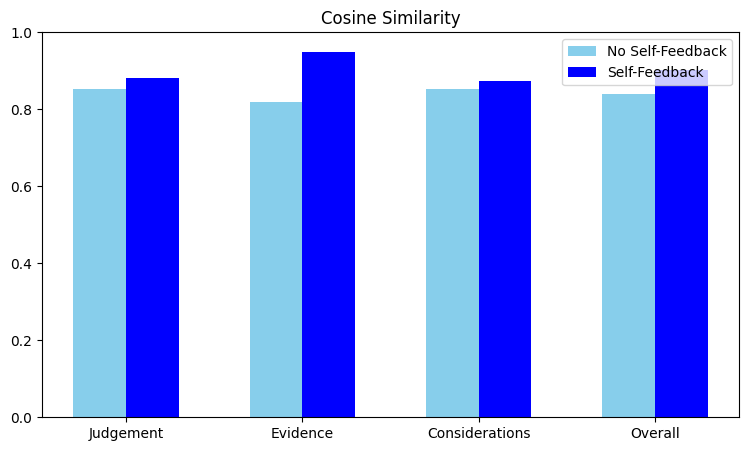

In [ ]:
# ---- 20a. Continuous Cosine Similarity ----
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

# Load evaluation results
eval_df = pd.read_csv("drive/My Drive/Master LAP/DL/dl4nlp/PROJECT/model/evaluation_results.csv")

# Load embedding model
device = "cuda" if torch.cuda.is_available() else "cpu"
embed_model = SentenceTransformer("intfloat/multilingual-e5-large", device=device)

def extract_section(text, keyword):
    """Extract a section robustly (case-insensitive)"""
    if not isinstance(text, str):
        return ""
    text_lower = text.lower()
    key_lower = keyword.lower()
    start = text_lower.find(key_lower)
    if start == -1:
        return ""
    start += len(key_lower)
    end = len(text)
    for next_kw in ["juicio", "evidencia", "consideraciones"]:
        if next_kw != key_lower:
            next_pos = text_lower.find(next_kw, start)
            if next_pos != -1:
                end = min(end, next_pos)
    return text[start:end].strip()

def cos_sim(a, b):
    if not a or not b:
        return 0.0
    emb_a = embed_model.encode(a, convert_to_tensor=True, normalize_embeddings=True)
    emb_b = embed_model.encode(b, convert_to_tensor=True, normalize_embeddings=True)
    return util.cos_sim(emb_a, emb_b).item()

# ---- Compute similarity for both predictions ----
metrics = ["Judgement", "Evidence", "Considerations", "Overall"]
results = {"no_feedback": {m: [] for m in metrics},
           "with_feedback": {m: [] for m in metrics}}

for _, row in eval_df.iterrows():
    gold = row["gold_doc"]

    for key, pred_col in [("no_feedback", "prediction_no_feedback"),
                          ("with_feedback", "prediction_with_feedback")]:
        pred = row[pred_col]

        juicio_sim = cos_sim(extract_section(pred, "JUICIO"), extract_section(gold, "JUICIO"))
        evidencia_sim = cos_sim(extract_section(pred, "EVIDENCIA"), extract_section(gold, "EVIDENCIA"))
        consideraciones_sim = cos_sim(extract_section(pred, "CONSIDERACIONES"), extract_section(gold, "CONSIDERACIONES"))
        overall_sim = (juicio_sim + evidencia_sim + consideraciones_sim) / 3

        results[key]["Judgement"].append(juicio_sim)
        results[key]["Evidence"].append(evidencia_sim)
        results[key]["Considerations"].append(consideraciones_sim)
        results[key]["Overall"].append(overall_sim)

# ---- Print summary ----
for key in results:
    print(f"\n=== Continuous Cosine Similarity ({key}) ===")
    for m in metrics:
        print(f"{m:25s}: {sum(results[key][m])/len(results[key][m]):.3f}")

# ---- Plot ----
x = metrics
no_fb_means = [sum(results["no_feedback"][m])/len(results["no_feedback"][m]) for m in metrics]
with_fb_means = [sum(results["with_feedback"][m])/len(results["with_feedback"][m]) for m in metrics]

plt.figure(figsize=(9,5))
plt.bar([i - 0.15 for i in range(len(x))], no_fb_means, width=0.3, label="No Self-Feedback", color="skyblue")
plt.bar([i + 0.15 for i in range(len(x))], with_fb_means, width=0.3, label="Self-Feedback", color="blue")
plt.ylim(0,1)
#plt.ylabel("Score")
plt.title("Cosine Similarity")
plt.xticks(range(len(x)), x)
plt.legend()
plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== BERTScore F1 (no_feedback) ===
Judgement                     : 0.702
Evidence                      : 0.625
Considerations                : 0.642
Overall                       : 0.656

=== BERTScore F1 (with_feedback) ===
Judgement                     : 0.727
Evidence                      : 0.893
Considerations                : 0.657
Overall                       : 0.759


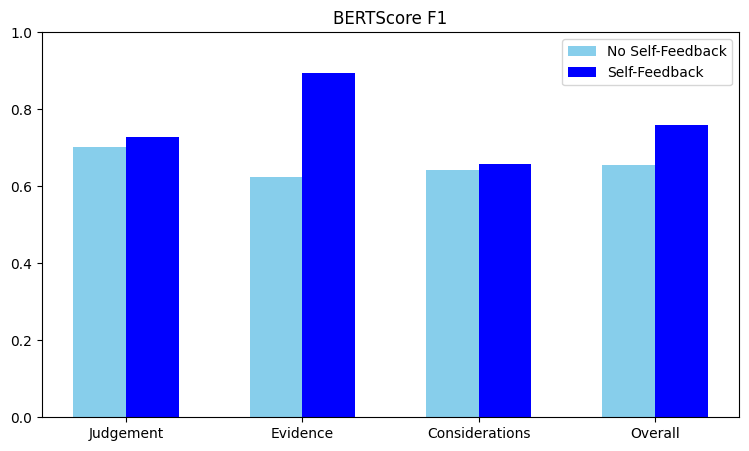

In [ ]:
# ---- 20b. BERTScore F1 ----
from bert_score import score
import matplotlib.pyplot as plt

# Prepare storage
metrics = ["Judgement", "Evidence", "Considerations", "Overall"]
results = {"no_feedback": {m: [] for m in metrics},
           "with_feedback": {m: [] for m in metrics}}

for _, row in eval_df.iterrows():
    gold = row["gold_doc"]

    for key, pred_col in [("no_feedback", "prediction_no_feedback"),
                          ("with_feedback", "prediction_with_feedback")]:
        pred = row[pred_col]

        # Extract sections
        juicio_pred = extract_section(pred, "JUICIO")
        evidencia_pred = extract_section(pred, "EVIDENCIA")
        consideraciones_pred = extract_section(pred, "CONSIDERACIONES")

        juicio_gold = extract_section(gold, "JUICIO")
        evidencia_gold = extract_section(gold, "EVIDENCIA")
        consideraciones_gold = extract_section(gold, "CONSIDERACIONES")

        # Compute BERTScore F1
        _, _, j_f1 = score([juicio_pred], [juicio_gold], lang="es", model_type="bert-base-multilingual-cased", verbose=False)
        _, _, e_f1 = score([evidencia_pred], [evidencia_gold], lang="es", model_type="bert-base-multilingual-cased", verbose=False)
        _, _, c_f1 = score([consideraciones_pred], [consideraciones_gold], lang="es", model_type="bert-base-multilingual-cased", verbose=False)

        j_f1 = j_f1.item()
        e_f1 = e_f1.item()
        c_f1 = c_f1.item()
        overall = (j_f1 + e_f1 + c_f1)/3

        results[key]["Judgement"].append(j_f1)
        results[key]["Evidence"].append(e_f1)
        results[key]["Considerations"].append(c_f1)
        results[key]["Overall"].append(overall)

# ---- Print summary ----
for key in results:
    print(f"\n=== BERTScore F1 ({key}) ===")
    for m in metrics:
        print(f"{m:30s}: {sum(results[key][m])/len(results[key][m]):.3f}")

# ---- Plot ----
x = metrics
no_fb_means = [sum(results["no_feedback"][m])/len(results["no_feedback"][m]) for m in metrics]
with_fb_means = [sum(results["with_feedback"][m])/len(results["with_feedback"][m]) for m in metrics]

plt.figure(figsize=(9,5))
plt.bar([i - 0.15 for i in range(len(x))], no_fb_means, width=0.3, label="No Self-Feedback", color="skyblue")
plt.bar([i + 0.15 for i in range(len(x))], with_fb_means, width=0.3, label="Self-Feedback", color="blue")
plt.ylim(0,1)
#plt.ylabel("Score")
plt.title("BERTScore F1")
plt.xticks(range(len(x)), x)
plt.legend()
plt.savefig("BERTScore.png", dpi=600, bbox_inches="tight")
plt.show()


=== ROUGE-L F1 (no_feedback) ===
Judgement                     : 0.000
Evidence                      : 0.000
Considerations                : 0.122
Overall                       : 0.041

=== ROUGE-L F1 (with_feedback) ===
Judgement                     : 0.000
Evidence                      : 0.689
Considerations                : 0.174
Overall                       : 0.288


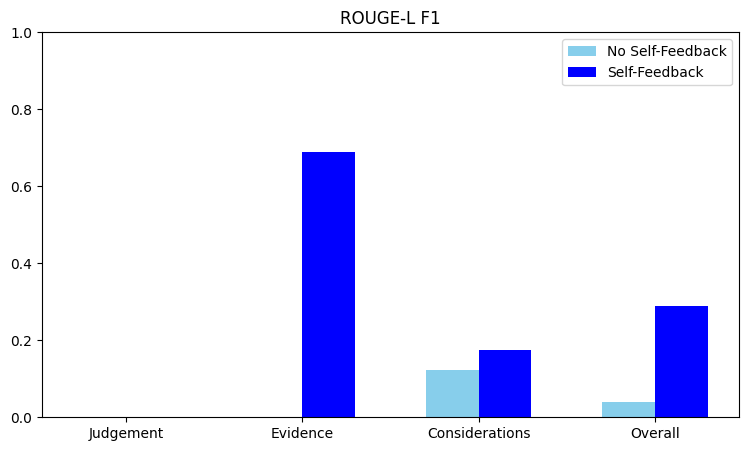

In [ ]:
# ---- 20c. ROUGE-L score ----
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

# Initialize scorer
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

metrics = ["Judgement", "Evidence", "Considerations", "Overall"]
results = {"no_feedback": {m: [] for m in metrics},
           "with_feedback": {m: [] for m in metrics}}

for _, row in eval_df.iterrows():
    gold = row["gold_doc"]

    for key, pred_col in [("no_feedback", "prediction_no_feedback"),
                          ("with_feedback", "prediction_with_feedback")]:
        pred = row[pred_col]

        # Extract sections
        juicio_pred = extract_section(pred, "JUICIO")
        evidencia_pred = extract_section(pred, "EVIDENCIA")
        consideraciones_pred = extract_section(pred, "CONSIDERACIONES")

        juicio_gold = extract_section(gold, "JUICIO")
        evidencia_gold = extract_section(gold, "EVIDENCIA")
        consideraciones_gold = extract_section(gold, "CONSIDERACIONES")

        # Compute ROUGE-L F1
        j_f1 = scorer.score(juicio_gold, juicio_pred)['rougeL'].fmeasure
        e_f1 = scorer.score(evidencia_gold, evidencia_pred)['rougeL'].fmeasure
        c_f1 = scorer.score(consideraciones_gold, consideraciones_pred)['rougeL'].fmeasure
        overall = (j_f1 + e_f1 + c_f1)/3

        results[key]["Judgement"].append(j_f1)
        results[key]["Evidence"].append(e_f1)
        results[key]["Considerations"].append(c_f1)
        results[key]["Overall"].append(overall)

# ---- Print summary ----
for key in results:
    print(f"\n=== ROUGE-L F1 ({key}) ===")
    for m in metrics:
        print(f"{m:30s}: {sum(results[key][m])/len(results[key][m]):.3f}")

# ---- Plot ----
x = metrics
no_fb_means = [sum(results["no_feedback"][m])/len(results["no_feedback"][m]) for m in metrics]
with_fb_means = [sum(results["with_feedback"][m])/len(results["with_feedback"][m]) for m in metrics]

plt.figure(figsize=(9,5))
plt.bar([i - 0.15 for i in range(len(x))], no_fb_means, width=0.3, label="No Self-Feedback", color="skyblue")
plt.bar([i + 0.15 for i in range(len(x))], with_fb_means, width=0.3, label="Self-Feedback", color="blue")
plt.ylim(0,1)
#plt.ylabel("Score")
plt.title("ROUGE-L F1")
plt.xticks(range(len(x)), x)
plt.legend()
plt.show()

ROUGE scores do not seem to be very useful for this model, because they compute strict lexical matching. However, semantic metrics (cosine similarity, BERTScore) show high performance, indicating correct content extraction.